In [41]:
import pypsa
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [42]:
years = range(2025, 2036)
path = Path.cwd().parent / 'results' / 'networks' 

#### Transport

In [43]:
valpath = Path.cwd().parent / 'data' / 'TYNDP_2024-Scenario-Report-Data-Figures_240522.xlsx'

In [44]:
def _extract_scenario_values(path, sheet_name, row_label):
    """
    Generic extractor for TYNDP 2024 scenario tables of the form:

        [0]      [1]          [2]             [3]             [4] ...
        NaN   Title row...
        NaN   NaN           Reference   National Trends(+)   ...
        NaN   NaN              2019                2030      ...

        NaN  <row_label>   value_ref   value_NT_2030   value_NT_2040 ...

    Returns a nested dict:
    {
        'National Trends': {2030: x, 2040: y, ...},
        'Distributed Energy': {...},
        'Global Ambition': {...}
    }
    """
    # Read raw (no header) to keep full structure
    df = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # 1. Find the scenario header row (the one that contains "National Trends")
    scen_row_candidates = []
    for idx in range(len(df)):
        row = df.iloc[idx, :]
        if row.astype(str).str.contains('National Trends', na=False).any():
            scen_row_candidates.append(idx)

    if not scen_row_candidates:
        raise ValueError(f"No scenario header row found in sheet {sheet_name}")

    scen_row = scen_row_candidates[0]
    year_row = scen_row + 1

    # 2. Map column -> scenario name (propagate across empty cells)
    scenario_by_col = {}
    last_scen = None
    for col in range(2, df.shape[1]):
        val = df.iat[scen_row, col]
        if pd.notna(val):
            sval = str(val).strip()
            if sval.startswith('National Trends'):
                last_scen = 'National Trends'
            elif sval.startswith('Distributed Energy'):
                last_scen = 'Distributed Energy'
            elif sval.startswith('Global Ambition'):
                last_scen = 'Global Ambition'
            elif sval.startswith('Reference'):
                last_scen = 'Reference'
            else:
                last_scen = sval
        scenario_by_col[col] = last_scen

    # 3. Map column -> year (from the row below the scenario names)
    year_by_col = {}
    for col in range(2, df.shape[1]):
        val = df.iat[year_row, col]
        if pd.isna(val):
            continue
        try:
            year = int(val)
        except (TypeError, ValueError):
            continue
        year_by_col[col] = year

    # 4. Find the row for the requested label (column 1)
    label_col = 1
    candidates = df.index[df.iloc[:, label_col] == row_label].tolist()
    if not candidates:
        raise ValueError(f"Row label '{row_label}' not found in sheet {sheet_name}")
    r = candidates[0]

    # 5. Build result dict (ignore the "Reference" column / 2019)
    result = {'National Trends': {}, 'Distributed Energy': {}, 'Global Ambition': {}}

    for col, scen in scenario_by_col.items():
        if scen not in result:
            continue
        year = year_by_col.get(col)
        if year is None:
            continue
        val = df.iat[r, col]
        if pd.isna(val):
            continue
        result[scen][year] = float(val)

    return result


def _extract_scenario_values_rowwise(path, sheet_name, carrier_label):
    """
    For tables like sheet '25-' where:
      - One header row contains "Scenario" and "Year"
      - Scenario names are in a column
      - Years are in a column
      - Energy carriers (e.g. 'Methane') are in that header row across columns

    Returns:
    {
        'National Trends': {2030: x, 2040: y, ...},
        'Distributed Energy': {...},
        'Global Ambition': {...}
    }
    """
    df = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # 1. Find header row (contains both "Scenario" and "Year")
    header_row = None
    for i in range(len(df)):
        row_str = df.iloc[i, :].astype(str)
        if row_str.str.contains("Scenario", na=False).any() and \
           row_str.str.contains("Year", na=False).any():
            header_row = i
            break

    if header_row is None:
        raise ValueError(f"No header row with 'Scenario' and 'Year' found in sheet {sheet_name}")

    header = df.iloc[header_row, :]

    # 2. Identify scenario and year columns
    scen_col = None
    year_col = None
    for c, val in enumerate(header):
        s = str(val).strip()
        if "Scenario" in s:
            scen_col = c
        if s.startswith("Year"):
            year_col = c

    if scen_col is None or year_col is None:
        raise ValueError(f"Could not identify Scenario/Year columns in sheet {sheet_name}")

    # 3. Find the column for the requested carrier (e.g. 'Methane')
    target_col = None
    for c, val in enumerate(header):
        if pd.isna(val):
            continue
        if str(val).strip() == carrier_label:
            target_col = c
            break

    if target_col is None:
        raise ValueError(f"Carrier label '{carrier_label}' not found in header row of sheet {sheet_name}")

    # 4. Walk down the table and collect values
    result = {
        'National Trends': {},
        'Distributed Energy': {},
        'Global Ambition': {}
    }

    current_scen = None

    for r in range(header_row + 1, len(df)):
        scen_raw = df.iat[r, scen_col]

        # Update current scenario when a label appears
        if isinstance(scen_raw, str) and scen_raw.strip():
            s = scen_raw.strip()
            if "National Trends" in s:
                current_scen = "National Trends"
            elif "Distributed Energy" in s:
                current_scen = "Distributed Energy"
            elif "Global Ambition" in s:
                current_scen = "Global Ambition"
            else:
                current_scen = None  # ignore other possible rows

        if current_scen not in result:
            continue

        year_raw = df.iat[r, year_col]
        try:
            year = int(year_raw)
        except (TypeError, ValueError):
            continue

        val = df.iat[r, target_col]
        if pd.isna(val):
            continue

        if year not in result[current_scen]:
            result[current_scen][year] = float(val)

    return result



In [45]:
# ---------------------------------------------------------------------------
# Final electricity demand per sector, EU27 (TWh)
# Sheet: '6-'  |  Row labels: 'Residential & Tertiary', 'Transport', 'Industry'
# ---------------------------------------------------------------------------

def final_electricity_residential_tertiary(path):
    return _extract_scenario_values(path, sheet_name='6-', row_label='Residential & Tertiary')


def final_electricity_transport(path):
    return _extract_scenario_values(path, sheet_name='6-', row_label='Transport')


def final_electricity_industry(path):
    return _extract_scenario_values(path, sheet_name='6-', row_label='Industry')


# ---------------------------------------------------------------------------
# Methane demand per sector, EU27 (TWh)
# Sheet: '8-'  |  Row labels (top table): 'Residential&Tertiary', 'Power Generation', 'Industry'
# ---------------------------------------------------------------------------

def methane_residential_tertiary(path):
    # Note: in the sheet, it's "Residential&Tertiary" (no spaces around &)
    return _extract_scenario_values(path, sheet_name='8-', row_label='Residential&Tertiary')


def power_generation_methane(path):
    return _extract_scenario_values(path, sheet_name='8-', row_label='Power Generation')


def methane_industry_energetic(path):
    return _extract_scenario_values(path, sheet_name='8-', row_label='Industry')


def methane_industry_nonenergetic(path):
    return _extract_scenario_values(path, sheet_name='8-', row_label='Non-energy use')


# ---------------------------------------------------------------------------
# Energy sources for District Heating, EU27 (TWh) – Methane only
# Sheet: '12-'  |  Row label: 'Methane'
# ---------------------------------------------------------------------------

def district_heating_methane(path):
    return _extract_scenario_values(path, sheet_name='12-', row_label='Methane')

In [46]:
# ---------------------------------------------------------------------------
# Primary energy supply mix, EU27 (TWh)
# Sheet: '19-'  |  Row label: 'Natural gas****', 'Oil', 'Coal', 'Biomass', 'Nuclear', 'Solar', 'Wind'
# ---------------------------------------------------------------------------

def methane_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Natural gas****')

def oil_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Oil')

def coal_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Coal')

def biomass_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Biomass')

def nuclear_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Nuclear')

def solar_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Solar')

def wind_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Wind')


coal_primary_total(valpath)

{'National Trends': {2030: 179.28163786885034, 2040: 65.70965104058754},
 'Distributed Energy': {2040: 166.0, 2050: 106.0},
 'Global Ambition': {2040: 182.8713004510878, 2050: 102.45937112834974}}

In [207]:
# ---------------------------------------------------------------------------
# Power capacity mix, EU27 (GW)
# Sheet: '25-'  |  Row label: Gas, Solar, Wind Onshore, Wind Offshore, Nuclear, Battery
# ---------------------------------------------------------------------------

def gas_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Methane')

def solar_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Solar')

def wind_onshore_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Wind Onshore')

def wind_offshore_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Wind Offshore')

def nuclear_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Nuclear')

def battery_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Battery')

In [48]:
# ---------------------------------------------------------------------------
# Power generation mix, EU27 (TWh)
# Sheet: '26-'  |  Row label: Gas, Solar, Wind Onshore, Wind Offshore, Nuclear, Battery
# ---------------------------------------------------------------------------

def gas_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Methane****')

def solar_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Solar**')

def wind_onshore_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Wind Onshore**')

def wind_offshore_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Wind Offshore**')

def nuclear_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Nuclear')

def battery_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Battery')

In [49]:
# ---------------------------------------------------------------------------
# Domestic gas production, EU27 (TWh)
# Sheet: '31-'  |  Row label: 'Natural gas (unabated)', 'Biomethane', 'Hydrogen (Green)', 'Hydrogen (Blue)', 'Hydrogen (Grey)', 'Synthetic methane'
# ---------------------------------------------------------------------------

def methane_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Natural gas (unabated)')

def biomethane_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Biomethane')

def green_hydrogen_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Hydrogen (Green)')

def blue_hydrogen_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Hydrogen (Blue)')

def grey_hydrogen_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Hydrogen (Grey)')

def synthetic_gas_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Synthetic methane')

In [50]:
# ---------------------------------------------------------------------------
# Methane Supply for EU27 (TWh)
# Sheet: '32-'  |  Row label: 'Natural gas (Import)', 'Natural gas (Domestic)', 'Biomethane (Import)', 'Biomethane (Domestic)', 'Synthetic methane (Import)', 'Synthetic methane (Domestic)'
# ---------------------------------------------------------------------------

def natural_gas_import(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Natural gas (Import)')

def natural_gas_domestic(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Natural gas (Domestic)')

def biomethane_import(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Biomethane (Import)')

def biomethane_domestic(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Biomethane (Domestic)')

def synthetic_methane_import(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Synthetic methane (Import)')

def synthetic_methane_domestic(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Synthetic methane (Domestic)')

In [51]:
natural_gas_import(valpath)

{'National Trends': {2030: 2794.224084520606, 2040: 1387.2426744121778},
 'Distributed Energy': {2040: 1021.5127437257339, 2050: 0.46383820301502965},
 'Global Ambition': {2040: 1118.5927146297327, 2050: -0.13316014037786772}}

In [52]:
wind_offshore_power_generation_mix(valpath)

{'National Trends': {2030: 411.5, 2040: 1113.4},
 'Distributed Energy': {2040: 1251.498203, 2050: 1664.6141198000005},
 'Global Ambition': {2040: 1218.4061354, 2050: 1746.9182663999995}}

In [53]:
print(final_electricity_residential_tertiary(valpath))

{'National Trends': {2030: 1507.757980079743, 2040: 1565.2847386976225}, 'Distributed Energy': {2040: 1353.7537810674248, 2050: 1283.3765667524513}, 'Global Ambition': {2040: 1363.6359370369842, 2050: 1261.702865689263}}


In [54]:
print(final_electricity_industry(valpath))

{'National Trends': {2030: 1140.6482818357456, 2040: 1324.84713849109}, 'Distributed Energy': {2040: 1593.726146647707, 2050: 1715.9871106288663}, 'Global Ambition': {2040: 1276.8148650115907, 2050: 1378.0806427823607}}


In [55]:
print(power_generation_methane(valpath))

{'National Trends': {2030: 971.5412546253085, 2040: 649.4704247699744}, 'Distributed Energy': {2040: 291.6853259292327, 2050: 153.9058407476516}, 'Global Ambition': {2040: 204.5339360297042, 2050: 103.6416758261583}}


In [56]:
print(district_heating_methane(valpath))

{'National Trends': {2030: 196.0048935308436, 2040: 148.5758460816616}, 'Distributed Energy': {2040: 185.0084482341095, 2050: 101.83595123308632}, 'Global Ambition': {2040: 167.16060774403712, 2050: 84.25757358374423}}


In [57]:
ns = {
    year: pypsa.Network(path / f'base_s_50__168H-T-H-B-I-A-dist1_{year}.nc')
    for year in years
}
n = ns[2025]

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2026.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2027.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2028.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2029.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, store

In [81]:
tyndp_ev_demand = final_electricity_transport(valpath)

In [64]:
import matplotlib.colors as mcolors

tyndp_colors = {
    'National Trends': '#fe4a49',
    'Distributed Energy': '#2ab7ca',
    'Global Ambition': '#fed766',
}

def darken_color(color, factor=0.7):
    rgb = mcolors.to_rgb(color)
    return tuple(c * factor for c in rgb)

In [82]:
tyndp_ev_demand

{'National Trends': {2030: 247.64143184472053, 2040: 488.45309616768986},
 'Distributed Energy': {2040: 616.8067207371424, 2050: 849.9178634898052},
 'Global Ambition': {2040: 533.8023438415136, 2050: 779.9316227533446}}

In [83]:
ev_load = list()
ice_load = list()

w = n.snapshot_weightings.generators.iloc[0]

for year in years:

    evs = ns[year].loads.index[ns[year].loads.carrier == 'land transport EV']
    ices = ns[year].loads.index[ns[year].loads.carrier == 'land transport oil']

    ev_load.append(ns[year].loads_t.p_set.loc[:, evs].sum().sum() * w * 1e-6)
    ice_load.append(ns[year].loads_t.p_set.loc[:, ices].sum().sum() * w * 1e-6)

In [105]:
def get_ylimmax(args):
    ylimmax = 0

    for arg in args:
        if isinstance(arg, list):
            ylimmax = max(ylimmax, max(arg))
        elif isinstance(arg, dict):
            ylimmax = max(ylimmax, max(
                [arg['National Trends'][2030], arg['National Trends'][2040], arg['Distributed Energy'][2040], arg['Global Ambition'][2040]]
                )
            )
    return ylimmax

In [151]:
def add_tyndp_legend(axs):
    # Add legend for TYNDP scenarios
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', markerfacecolor=tyndp_colors['National Trends'], 
            markeredgecolor=darken_color(tyndp_colors['National Trends']), 
            markersize=10, color='w', label='National Trends', alpha=0.5),
        Line2D([0], [0], marker='o', markerfacecolor=tyndp_colors['Distributed Energy'], 
            markeredgecolor=darken_color(tyndp_colors['Distributed Energy']), 
            markersize=10, color='w', label='Distributed Energy', alpha=0.5),
        Line2D([0], [0], marker='o', markerfacecolor=tyndp_colors['Global Ambition'], 
            markeredgecolor=darken_color(tyndp_colors['Global Ambition']), 
            markersize=10, color='w', label='Global Ambition', alpha=0.5),
    ]
    axs[-1].legend(
        title='TYNDP Scenarios',
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        ncol=1,
        frameon=False,
        )

In [148]:
def data_to_plot(
    ax,
    years,
    model_data,
    tyndp_data=None,
    title=None,
    ylabel=None,
    ylimmax=None,
    ):

    color = np.random.rand(3,)
    ax.plot(years, model_data, marker='o', color=color)

    gradient = (model_data[-1] - model_data[len(years)//2]) / (years[-1] - years[len(years)//2])

    extrapolation_years = [years[-1], 2040]
    extrapolation = [model_data[-1], model_data[-1] + gradient * (2040 - years[-1])]

    ax.plot(extrapolation_years, extrapolation, linestyle='--', color=color)

    if title is not None:
        ax.set_title(title)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    used_data = [0]
    if tyndp_data is not None:
        ax.scatter(
            [2030, 2040],
            [tyndp_data['National Trends'][2030], tyndp_data['National Trends'][2040]],
            color=tyndp_colors['National Trends'],
            edgecolors=darken_color(tyndp_colors['National Trends']),
            s=100,
            alpha=0.5,
            )
        ax.scatter(
            [2040],
            [tyndp_data['Distributed Energy'][2040]],
            color=tyndp_colors['Distributed Energy'],
            edgecolors=darken_color(tyndp_colors['Distributed Energy']),
            s=100,
            alpha=0.5,
            )
        ax.scatter(
            [2040],
            [tyndp_data['Global Ambition'][2040]],
            color=tyndp_colors['Global Ambition'],
            edgecolors=darken_color(tyndp_colors['Global Ambition']),
            s=100,
            alpha=0.5,
        )
        used_data = [
            tyndp_data['National Trends'][2030],
            tyndp_data['National Trends'][2040],
            tyndp_data['Distributed Energy'][2040],
            tyndp_data['Global Ambition'][2040],
        ]

    if ylimmax is None:
        ax.set_ylim(0, max(max(model_data), max(used_data)) * 1.1)
    else:
        ax.set_ylim(0, ylimmax)

    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Year')

    ax.set_xlim(2024, 2041)
    ax.set_xticks([2025, 2030, 2035, 2040])

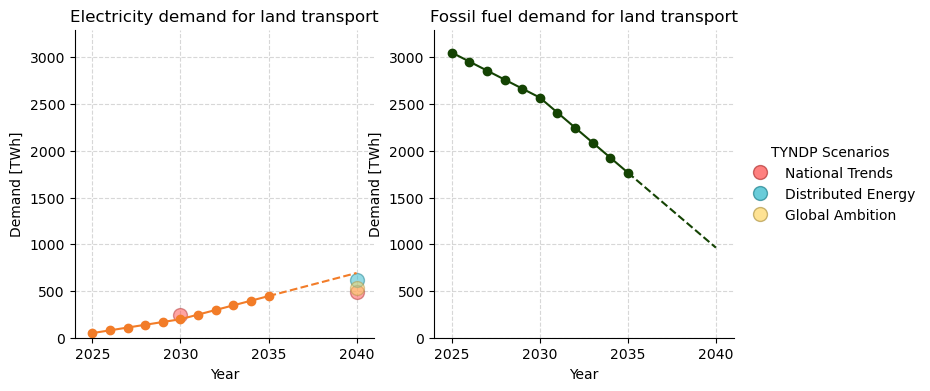

In [149]:
fig, axs = plt.subplots(1, 2, figsize=(8.5, 4))

ylimmax = get_ylimmax([ev_load, ice_load, tyndp_ev_demand]) * 1.08

data_to_plot(axs[0], years, ev_load, tyndp_data=tyndp_ev_demand, title='Electricity demand for land transport', ylabel='Demand [TWh]', ylimmax=ylimmax)
data_to_plot(axs[1], years, ice_load, title='Fossil fuel demand for land transport', ylabel='Demand [TWh]', ylimmax=ylimmax)

add_tyndp_legend(axs)

plt.show()

In [139]:
idx = pd.IndexSlice

heating_carriers = [
    'urban decentral heat',
    'urban central heat',
    'rural heat',
]

In [140]:
tyndp_gas_heating = methane_residential_tertiary(valpath)

In [141]:
tyndp_gas_heating

{'National Trends': {2030: 989.9205288794308, 2040: 598.5175082850943},
 'Distributed Energy': {2040: 504.49787027431285, 2050: 269.3644992267002},
 'Global Ambition': {2040: 600.529347439855, 2050: 302.77064659026394}}

In [142]:
indicators = ['gas boiler', 'biomass boiler', 'resistive heater', 'heat pump', 'oil boiler']

def clean_carrier(carrier):
    if len(matches := [ind for ind in indicators if ind in carrier]) > 0:
        return matches[0]
    else:
        return 'other'


data = []

for year in years:
    try:
        eb = ns[year].statistics.energy_balance().loc[
            idx[:, :, heating_carriers]
            ].sort_values()
    except KeyError:
        continue

    grouper = {
        carrier: clean_carrier(carrier)
        for carrier in eb.index.get_level_values(1)
    }

    eb.index = eb.index.get_level_values(1)
    eb = eb.groupby(grouper).sum().drop('other').mul(1e-6)

    data.append(eb.rename(year))

data = pd.concat([d.to_frame() for d in data], axis=1)

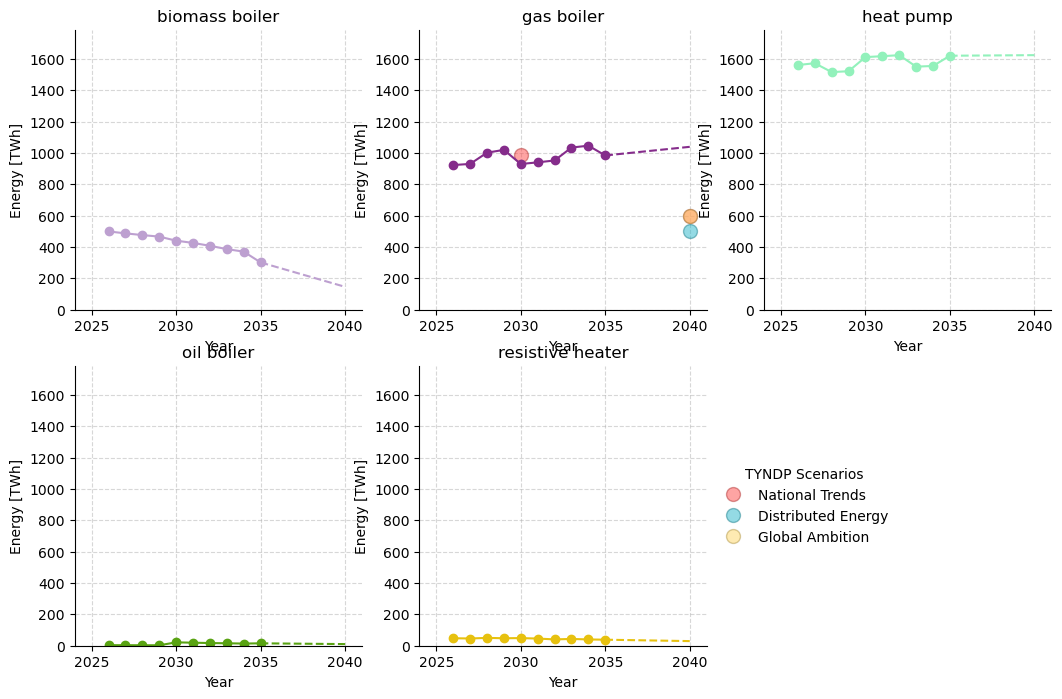

In [155]:
ylimmax = data.max().max() * 1.1

fig, axs = plt.subplots(2, 3, figsize=(3 * 4.2, 8))

for i, (name, row) in enumerate(data.iterrows()):

    ax = axs.flatten()[i]

    if name == 'gas boiler':
        kwargs = {'tyndp_data': tyndp_gas_heating}
    else:
        kwargs = {}

    data_to_plot(ax, row.index, list(row), title=name, ylabel='Energy [TWh]', ylimmax=ylimmax, **kwargs)

axs.flatten()[-1].set_visible(False)
add_tyndp_legend(axs.flatten()[:-1])

plt.show()

In [57]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [181]:
industry_loads = [
    'gas for industry',
    'H2 for industry',
    'naphtha for industry',
    'coal for industry',
    'low-temperature heat for industry',
    'industry electricity',
    'solid biomass for industry',
    'industry methanol',
]

data = []

for year in years:

    year_loads = []

    for load in industry_loads:
        index = n.loads.index[n.loads.carrier == load]
        
        try:
            year_loads.append(ns[year].loads_t.p_set.loc[:, index].sum().sum() * w * 1e-6)
        except KeyError:
            year_loads.append(ns[year].loads.loc[index, 'p_set'].sum() * w * 1e-6 * len(n.snapshots))

    year_loads = pd.DataFrame({year: year_loads}, index=industry_loads)
    data.append(year_loads)

data = pd.concat(data, axis=1)

In [182]:
def add_dict_leaves(dict1, dict2):
    """Add all leaf nodes of two dicts with the same structure."""
    result = {}
    for key in dict1:
        if isinstance(dict1[key], dict):
            result[key] = add_dict_leaves(dict1[key], dict2[key])
        else:
            result[key] = dict1[key] + dict2[key]
    return result


In [183]:
gas_industry_energetic = methane_industry_energetic(valpath)
gas_industry_nonenergetic = methane_industry_nonenergetic(valpath)
gas_industry = add_dict_leaves(gas_industry_energetic, gas_industry_nonenergetic)
gas_industry

{'National Trends': {2030: 1054.5708898045905, 2040: 710.0269618790448},
 'Distributed Energy': {2040: 559.6370633349316, 2050: 286.3726374181465},
 'Global Ambition': {2040: 676.8503679772065, 2050: 380.9271647444467}}

In [184]:
electricity_industry = final_electricity_industry(valpath)

In [189]:
ylimmax = get_ylimmax([data.values.flatten(), gas_industry, electricity_industry]) * 1.1

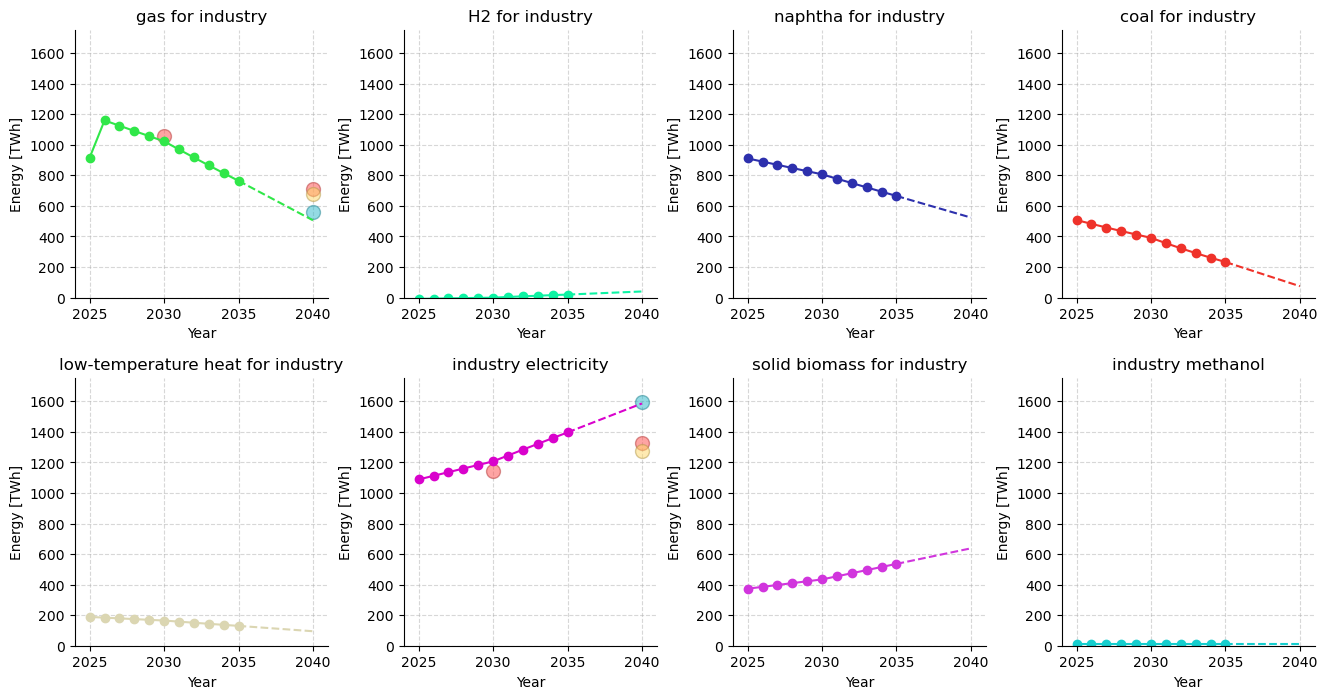

In [190]:
fig, axs = plt.subplots(2, len(industry_loads)//2, figsize=(len(industry_loads)//2 * 4, 8))

for i, (name, row) in enumerate(data.iterrows()):
    ax = axs.flatten()[i]

    if name == 'gas for industry':
        kwargs = {'tyndp_data': gas_industry}
    elif name == 'industry electricity':
        kwargs = {'tyndp_data': electricity_industry}
    else:
        kwargs = {}

    data_to_plot(ax, row.index, list(row), title=name, ylabel='Energy [TWh]', ylimmax=ylimmax, **kwargs)


fig.subplots_adjust(hspace=0.3, wspace=0.3)

plt.show()

In [170]:
cs = n.statistics.optimal_capacity().index.get_level_values(1).unique()
[c for c in cs if 'umped' in c]

['Pumped Hydro Storage']

In [171]:
capacities = {
    'offwind': ['Offshore Wind (AC)', 'Offshore Wind (DC)', 'Offshore Wind (Floating)'],
    'onwind': ['Onshore Wind'],
    'solar': ['Solar', 'solar-hsat'],
    'hydro': ['Run of River', 'Reservoir & Dam'],
    'gas': ['Combined-Cycle Gas', 'Open-Cycle Gas'],
    'coal': ['coal', 'lignite'],
    'nuclear': ['nuclear'],
    'battery': ['Battery Storage'],
    'PHS': ['Pumped Hydro Storage'],
    'electrolyser': ['H2 Electrolysis'],
}

In [172]:
'nuclear' in n.statistics.optimal_capacity().index.get_level_values(1).unique()

True

In [173]:
n.statistics.optimal_capacity().loc[idx[:, 'nuclear']]

component
Generator    105286.10000
Link         318877.60736
dtype: float64

In [234]:
gas_capacity = gas_power_capacity_mix(valpath)
solar_capacity = solar_power_capacity_mix(valpath)
onwind_capacity = wind_onshore_power_capacity_mix(valpath)
offwind_capacity = wind_offshore_power_capacity_mix(valpath)
nuclear_capacity = nuclear_power_capacity_mix(valpath)
battery_capacity = battery_power_capacity_mix(valpath)

data = []

for year in years:

    year_caps = []
    caps = ns[year].statistics.optimal_capacity()

    for name, carriers in capacities.items():
        
        if name in ['coal', 'gas']:
            year_caps.append(caps.loc[idx['Link', carriers]].sum() * 1e-3)
        elif name in ['nuclear']:
            year_caps.append(caps.loc[idx['Generator', carriers]].sum() * 1e-3)
        else:
            year_caps.append(caps.loc[idx[:, carriers]].sum() * 1e-3)

    year_caps = pd.DataFrame({year: year_caps}, index=capacities.keys())
    data.append(year_caps)

data = pd.concat(data, axis=1)
data


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035
offwind,53.874729,55.473433,57.700552,58.995793,60.733587,62.070386,63.581700,66.827511,70.385887,72.162765,74.610811
onwind,347.713820,357.113508,366.013236,373.717363,376.181783,392.444345,407.838708,417.176585,424.218815,423.828916,426.763321
solar,642.814508,669.807282,689.009421,712.548680,750.290780,826.126649,879.202980,925.916481,960.564509,1017.246250,1072.388053
hydro,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994
gas,333.826792,333.143197,333.491260,331.759847,330.403452,328.731657,328.519478,325.416471,325.104203,324.701109,316.112896
coal,295.812914,261.618256,249.367800,228.414160,186.580748,156.666111,131.736153,122.273808,113.178507,98.495541,96.078417
nuclear,105.286100,105.286100,105.286100,105.286100,105.286100,105.286100,105.286100,105.286100,105.286100,105.286100,105.286100
battery,0.002877,0.002864,0.001785,0.001885,0.002038,0.001248,0.001793,0.001355,0.001665,0.000737,0.001018
PHS,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136
electrolyser,0.000368,0.000445,0.000278,0.000260,0.000272,0.030587,0.030669,0.030596,0.030652,0.030494,0.030559


In [235]:
ylimmax = get_ylimmax([
    data.values.flatten(),
    gas_capacity,
    solar_capacity,
    onwind_capacity,
    offwind_capacity,
    nuclear_capacity,
    battery_capacity
    ]) * 1.1

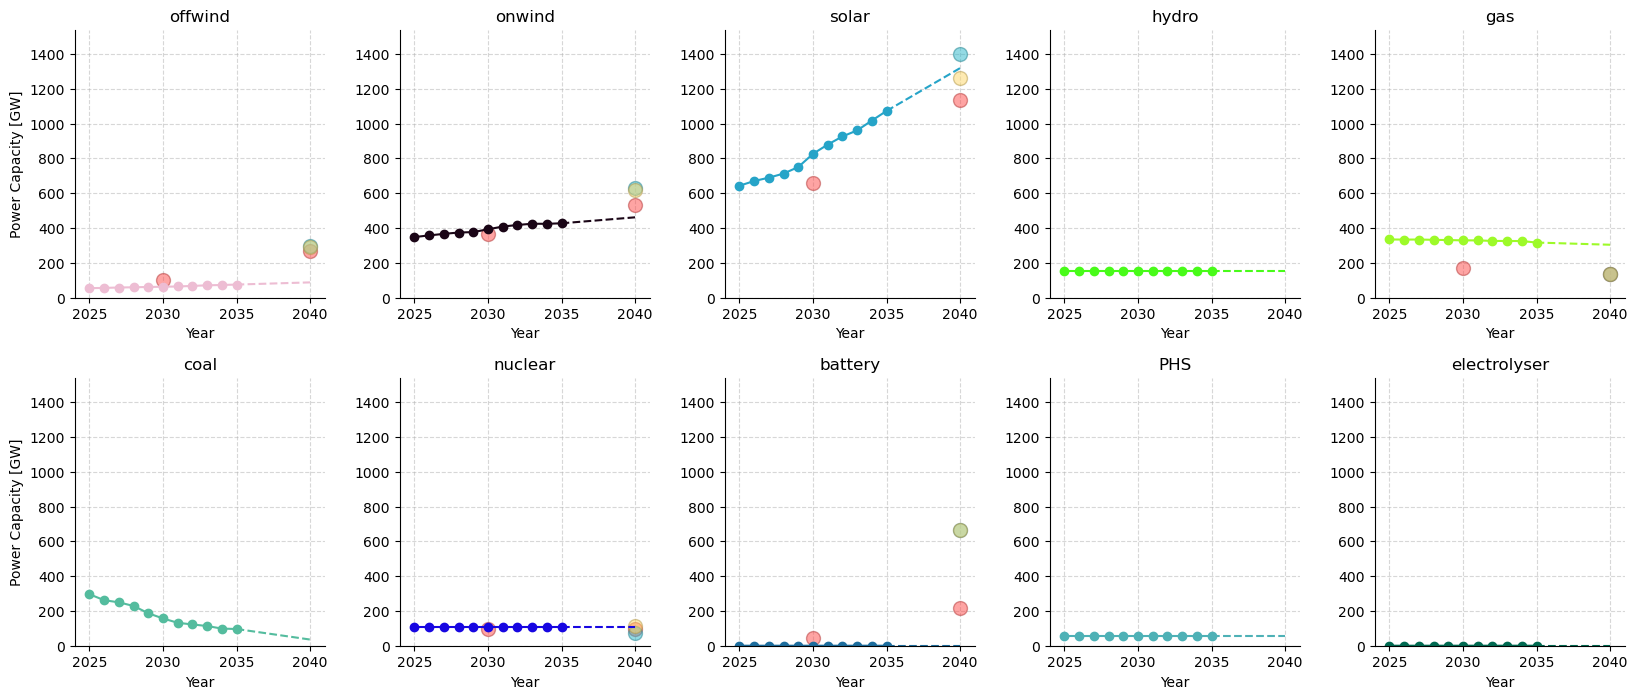

In [236]:
fig, axs = plt.subplots(2, len(capacities)//2, figsize=(len(capacities)//2 * 4, 8))

for i, (name, row) in enumerate(data.iterrows()):
    ax = axs.flatten()[i]

    if name+'_capacity' in globals():
        kwargs = {'tyndp_data': globals()[name+'_capacity']}
    else:
        kwargs = {}
    
    data_to_plot(ax, row.index, list(row), title=name, ylimmax=ylimmax, **kwargs)

for ax in axs[:,0]:
    ax.set_ylabel('Power Capacity [GW]')

fig.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

In [213]:
mix = ns[year].statistics.supply()
mix

component  carrier                           
Generator  Offshore Wind (AC)                    1.689431e+08
           Offshore Wind (DC)                    8.356658e+07
           Offshore Wind (Floating)              5.875238e+02
           Onshore Wind                          8.231612e+08
           Run of River                          1.625267e+08
                                                     ...     
Link       urban central solid biomass CHP       1.314333e+08
           urban central solid biomass CHP CC    1.811313e+03
           urban decentral oil boiler            2.430703e+06
           urban decentral resistive heater      3.963510e+07
Line       AC                                    9.911063e+08
Length: 101, dtype: float64

In [228]:
mix.loc[idx[:, 'uranium']]

component
Store    0.16113
dtype: float64

In [230]:
n.generators.loc[n.generators.carrier == 'nuclear', 'p_nom_opt'].sum()

105286.1

In [227]:
mix.index.get_level_values(1).unique()

Index(['Offshore Wind (AC)', 'Offshore Wind (DC)', 'Offshore Wind (Floating)',
       'Onshore Wind', 'Run of River', 'Solar', 'biogas', 'coal', 'gas',
       'lignite', 'nuclear', 'oil primary', 'residential rural solar thermal',
       'residential urban decentral solar thermal', 'solar-hsat',
       'solid biomass', 'unsustainable biogas', 'unsustainable bioliquids',
       'unsustainable solid biomass', 'urban central solar thermal',
       'H2 for industry', 'process emissions', 'Pumped Hydro Storage',
       'Reservoir & Dam', 'Battery Storage', 'EV battery', 'H2 Store',
       'ammonia store', 'co2 stored', 'home battery', 'methanol',
       'non-sequestered HVC', 'oil', 'uranium', 'BEV charger', 'CO2 pipeline',
       'Combined-Cycle Gas', 'DC', 'Fischer-Tropsch', 'H2 Electrolysis',
       'HVC to air', 'Haber-Bosch', 'OCGT methanol', 'Open-Cycle Gas', 'SMR',
       'SMR CC', 'Sabatier', 'V2G', 'agriculture machinery oil',
       'ammonia cracker', 'battery charger', 'battery d

In [237]:
mix.loc[idx[:, 'nuclear']]

component
Generator    6.222830e+08
Link         5.470000e-02
dtype: float64

In [ ]:
n.buses.loc[n.buses.carrier == 'uranium']

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_lv,location,country,substation_off
Bus,,,,,,,,,,,,,,,,
EU uranium,1.0,,-5.5,46.0,uranium,MWh_th,1.0,0.0,inf,PQ,,,NaN,EU,,NaN


In [258]:
eta = n.links.loc[n.links.carrier == 'nuclear', 'efficiency'].iloc[0]
n.links.loc[n.links.carrier == 'nuclear'].groupby('bus1')[['p_nom_opt', 'p_nom']].sum() * eta

,p_nom_opt,p_nom
bus1,,
BE0 0,5919.0,5919.0
BG0 0,2080.0,2080.0
CH0 0,2970.0,2970.0
CZ0 0,4164.0,4164.0
ES0 0,4084.4,4084.4
ES6 0,3032.8,3032.8
FI1 0,4362.0,4362.0
FR0 0,22240.0,22240.0
FR0 1,9910.0,9910.0


In [263]:
gas_mix = gas_power_generation_mix(valpath)
solar_mix = solar_power_generation_mix(valpath)
onwind_mix = wind_onshore_power_generation_mix(valpath)
offwind_mix = wind_offshore_power_generation_mix(valpath)
nuclear_mix = nuclear_power_generation_mix(valpath)
battery_mix = battery_power_generation_mix(valpath)

data = []

for year in years:

    year_mix = []
    mixes = ns[year].statistics.supply()

    for name, carriers in capacities.items():

        if name in ['coal', 'gas']:
            year_mix.append(mixes.loc[idx['Link', carriers]].sum() * 1e-6)
        else:
            year_mix.append(mixes.loc[idx[:, carriers]].sum() * 1e-6)

    year_mix = pd.DataFrame({year: year_mix}, index=capacities.keys())
    data.append(year_mix)


data = pd.concat(data, axis=1)
data

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035
offwind,252.510285,261.016510,273.285288,277.362436,286.702894,293.513580,300.789336,315.614858,331.707665,3.410110e+02,3.531921e+02
onwind,823.161150,849.162085,872.975663,897.695729,912.502708,956.094925,998.895834,1025.380375,1047.040280,1.065058e+03,1.071675e+03
solar,974.364166,1021.018611,1053.175203,1091.118073,1152.878273,1248.785892,1316.322821,1375.591697,1420.614308,1.493319e+03,1.564840e+03
hydro,494.285264,494.287080,494.291126,494.291629,494.291497,494.266730,494.260515,494.261048,494.252131,4.942685e+02,4.942236e+02
gas,121.309022,133.761694,143.384139,134.728231,160.286607,152.405846,166.942110,179.989335,173.292898,1.956957e+02,2.195195e+02
coal,546.561863,491.100257,471.639166,435.640008,349.861217,296.673222,259.027160,243.970307,231.111739,2.084769e+02,2.045192e+02
nuclear,622.282966,619.676679,619.421806,619.097958,618.619431,596.836216,590.460143,586.183262,586.356169,5.802358e+02,5.758885e+02
battery,0.000003,0.000004,0.000002,0.000003,0.000002,0.000001,0.000002,0.000001,0.000002,5.057500e-07,9.128200e-07
PHS,12.917239,12.641254,12.444039,12.507538,12.345601,12.650308,13.110008,13.296072,13.017984,1.207775e+01,1.319199e+01
electrolyser,0.001260,0.001635,0.000982,0.000900,0.000925,0.180739,0.181030,0.180757,0.179497,1.066583e-01,1.442493e-01


In [264]:
ylimmax = get_ylimmax([
    data.values.flatten(),
    gas_mix,
    solar_mix,
    onwind_mix,
    offwind_mix,
    nuclear_mix,
    battery_mix
    ]) * 1.1

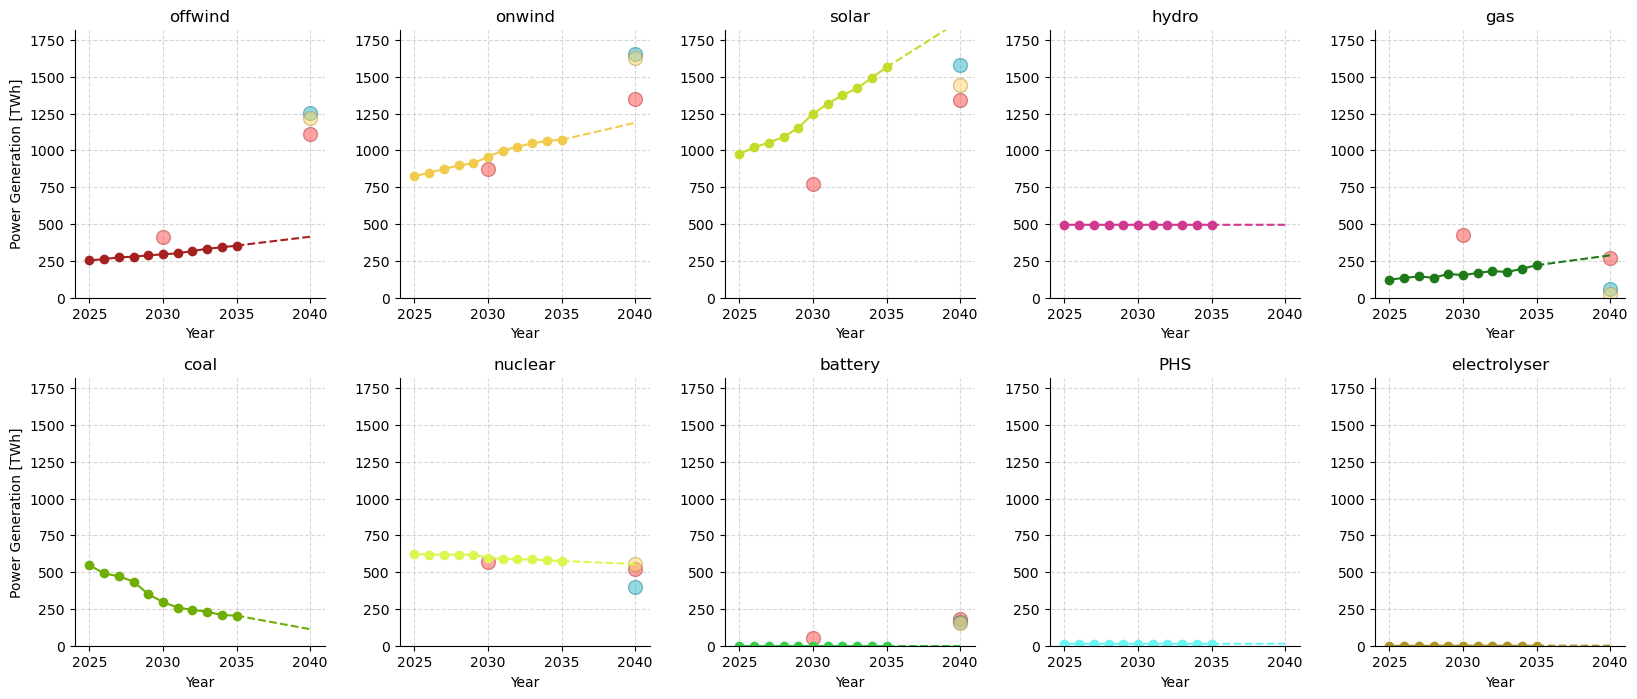

In [265]:
fig, axs = plt.subplots(2, len(capacities)//2, figsize=(len(capacities)//2 * 4, 8))

for i, (name, row) in enumerate(data.iterrows()):
    ax = axs.flatten()[i]

    if name+'_mix' in globals():
        kwargs = {'tyndp_data': globals()[name+'_mix']}
    else:
        kwargs = {}
    
    data_to_plot(ax, row.index, list(row), title=name, ylimmax=ylimmax, **kwargs)

for ax in axs[:,0]:
    ax.set_ylabel('Power Generation [TWh]')

fig.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

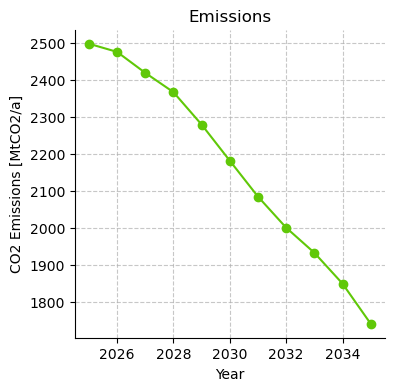

In [211]:
gens = n.generators.index[n.generators.carrier == 'co2-ets']

emissions = []

for year in years:
    emissions.append(ns[year].generators_t.p.loc[:, gens].sum().sum() * w * -1e-6)

emissions = pd.DataFrame({'emissions': emissions}, index=years)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

emissions['emissions'].plot(ax=ax, marker='o', color=np.random.rand(3,))
ax.set_title('Emissions')

ax.grid(True, linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Year')

ax.set_ylabel('CO2 Emissions [MtCO2/a]')

plt.show()